In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

In [4]:
df=pd.read_csv("Fuel.csv")
df.head(5)

,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              639 non-null    int64  
 1   MAKE              639 non-null    object 
 2   MODEL             639 non-null    object 
 3   VEHICLE CLASS     639 non-null    object 
 4   ENGINE SIZE       639 non-null    float64
 5   CYLINDERS         639 non-null    int64  
 6   TRANSMISSION      639 non-null    object 
 7   FUEL              639 non-null    object 
 8   FUEL CONSUMPTION  639 non-null    float64
 9   COEMISSIONS       639 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 50.1+ KB


In [6]:
df.describe()

,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,639.0,639.000000,639.000000,639.000000,639.000000
mean,2000.0,3.265728,5.805947,14.713615,296.809077
std,0.0,1.231012,1.625588,3.307044,65.504178
min,2000.0,1.000000,3.000000,4.900000,104.000000
25%,2000.0,2.200000,4.000000,12.500000,253.000000
50%,2000.0,3.000000,6.000000,14.400000,288.000000
75%,2000.0,4.300000,6.000000,16.600000,343.000000
max,2000.0,8.000000,12.000000,30.200000,582.000000


In [7]:
df.isnull().sum()

Year                0
MAKE                0
MODEL               0
VEHICLE CLASS       0
ENGINE SIZE         0
CYLINDERS           0
TRANSMISSION        0
FUEL                0
FUEL CONSUMPTION    0
COEMISSIONS         0
dtype: int64

In [8]:
df=df.drop(['MODEL','Year'], axis=1)
df.head()

,MAKE,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,ACURA,COMPACT,1.6,4,A4,X,10.5,216
1,ACURA,COMPACT,1.6,4,M5,X,9.8,205
2,ACURA,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,ACURA,MID-SIZE,3.5,6,A4,Z,15.0,301
4,ACURA,SUBCOMPACT,1.8,4,A4,X,11.4,230


In [9]:
df.columns = df.columns.str.strip()
df

,MAKE,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,ACURA,COMPACT,1.6,4,A4,X,10.5,216
1,ACURA,COMPACT,1.6,4,M5,X,9.8,205
2,ACURA,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,ACURA,MID-SIZE,3.5,6,A4,Z,15.0,301
4,ACURA,SUBCOMPACT,1.8,4,A4,X,11.4,230
...,...,...,...,...,...,...,...,...
634,VOLVO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,14.4,288
635,VOLVO,STATION WAGON - MID-SIZE,2.4,5,A4,Z,13.6,274
636,VOLVO,STATION WAGON - MID-SIZE,2.3,5,A4,Z,13.9,274
637,VOLVO,STATION WAGON - MID-SIZE,2.3,5,M5,Z,13.0,260


In [10]:
X = df.drop("COEMISSIONS", axis=1)
y = df["COEMISSIONS"]

In [11]:
X = pd.get_dummies(X)

## Exploratory Data Analysis

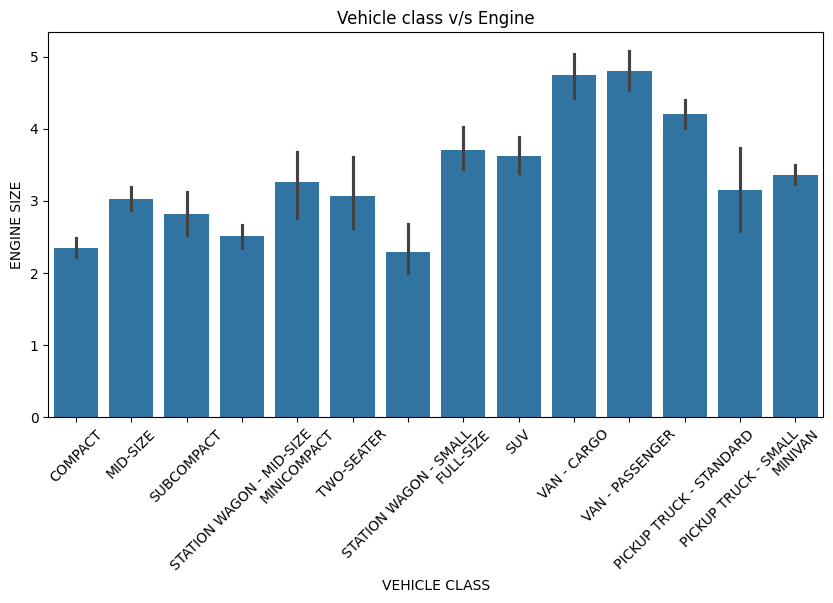

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='VEHICLE CLASS', y='ENGINE SIZE')
plt.title("Vehicle class v/s Engine")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='ENGINE SIZE', ylabel='FUEL CONSUMPTION'>

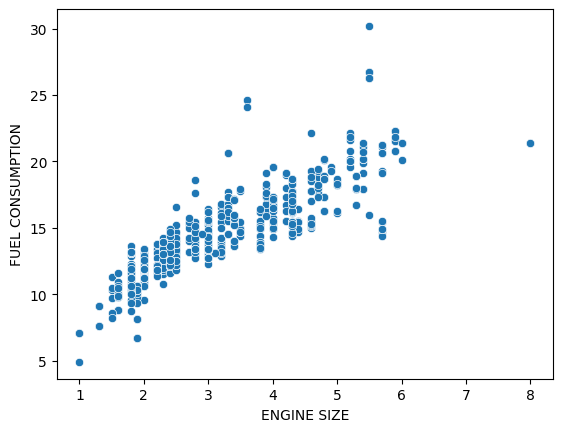

In [13]:
sns.scatterplot(data=df, x="ENGINE SIZE", y="FUEL CONSUMPTION")

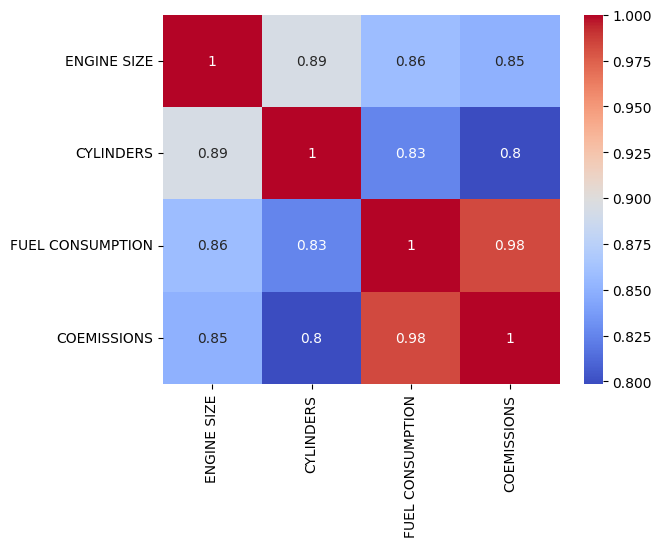

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

## Model Training

In [17]:
X = df[["ENGINE SIZE", "CYLINDERS"]]
y = df["COEMISSIONS"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
print("Model Score:", model.score(X_test, y_test))

Model Score: 0.6899381041267392


In [21]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

## ✅ Problem Statement

Predicting vehicle CO₂ emissions accurately is critical for environmental monitoring and regulatory compliance.
Traditional approaches rely on multiple vehicle parameters such as fuel type, fuel consumption, and engine characteristics. However, this creates challenges in real-world deployment:

Data collection becomes complex and time-consuming.

Many features are unavailable in real-time systems.

High model complexity increases latency and reduces scalability.

Maintaining consistency between training and deployment pipelines is difficult.

Therefore, there is a need for a lightweight, interpretable, and fast prediction system that can estimate CO₂ emissions using minimal input features while maintaining reasonable accuracy.

## ✅ Problem Faced During Deployment

During model deployment using FastAPI, a feature mismatch error occurred because:

1. The model was trained using multiple features including fuel consumption and encoded fuel type.

2. The deployed API was designed to accept only ENGINE SIZE and CYLINDERS.

3. This caused runtime errors since the model expected the same feature set used during training.

4. This highlighted a common real-world issue in machine learning:
👉 Inconsistency between training and inference pipelines.

## ✅ Solution Implemented

To solve this problem:

### ✔ Feature Simplification

The model was retrained using only:

ENGINE SIZE

CYLINDERS

This reduced model complexity and made it suitable for real-time use.

### ✔ Model Retraining

A new regression model was trained with the selected features to ensure:

Consistent feature input

Reduced risk of deployment errors

Faster predictions

### ✔ End-to-End Deployment

The solution was deployed as a REST API using FastAPI, enabling:

Real-time prediction

Scalable integration with applications

Easy testing via Swagger UI

### ✔ Robust System Design

The deployment pipeline ensured:

Consistent preprocessing

Structured API input validation

Production-ready architecture

## ✅ Key Results and Impact

Reduced model complexity and input requirements

Improved system interpretability

Enabled real-time prediction with low latency

Solved feature mismatch and deployment challenges

Created a scalable and lightweight CO₂ prediction system

## ✅ Business Value

This solution can help:

Environmental agencies estimate emissions quickly

Automotive companies evaluate eco-friendliness

Smart city platforms monitor vehicle pollution

Policy makers design sustainable transportation strategies

## 🎯 One-line Interview Pitch

👉 “I built and deployed a lightweight CO₂ emission prediction system using only key engine features, solving real-world deployment challenges like feature mismatch and ensuring fast, scalable predictions through a FastAPI-based architecture.”